In [2]:
import os
import time
import datetime

import numpy as np
import nc_time_axis
import pandas as pd
import xarray as xr

from glob import glob
from os.path import join

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [4]:
site = 'DE-Tha'  # Test site we're going to look at
experiment = '_FLUX' # Can set to ad, postad, or transient

# Change your $User to set the path to your archive directory
archive = '/glade/derecho/scratch/$User/archive/'

# Create a path to the data folder
data_folder = archive+'/'+site+experiment+'/lnd/hist'

'/glade/derecho/scratch/$User/archive//DE-Tha_FLUX/lnd/hist'

In [5]:
# Define function to preprocess all variables from the netcdf files
# This just drops an unused coordinate variable (lndgrid) from the dataset
def preprocess_all (ds):
    ds_new= ds.isel(lndgrid=0) 
    return ds_new

In [9]:
!ls /glade/derecho/scratch/$User/archive//DE-Tha_FLUX/lnd/hist

DE-Tha_FLUX.clm2.h0a.0001-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0002-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0003-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0004-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0005-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0006-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0007-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0008-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0009-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0010-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0011-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0012-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0013-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0014-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0015-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0016-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0017-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0018-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0019-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0020-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0021-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0022-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0023-02-01-00000.nc
DE-Tha_FLUX.clm2.h0a.0024-02-01-00000.nc
DE-Tha_FLUX.clm2

In [10]:
# Create an empty list of all the file names to extend
sim_files = []
sim_files.extend(sorted(glob(join(data_folder,"*h0a.*.nc"))))

print("All simulation files for all years: [", len(sim_files), "files]")
print(sim_files[-1])

All simulation files for all years: [ 200 files]
/glade/derecho/scratch/$User/archive//DE-Tha_FLUX/lnd/hist/DE-Tha_FLUX.clm2.h0a.0200-02-01-00000.nc


In [12]:
start = time.time()
print ("Reading in data for "+site)

ds_ctsm = xr.open_mfdataset(sim_files, decode_times=True, combine='by_coords',
                            preprocess=preprocess_all)

end = time.time()
print("Reading all simulation files took:", end-start, "s.")

Reading in data for DE-Tha


Reading all simulation files took: 35.321692943573 s.


/glade/derecho/scratch/$User/tmp/ipykernel_48385/3896015759.py:4: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_ctsm = xr.open_mfdataset(sim_files, decode_times=True, combine='by_coords',


In [13]:
# Check the structure of combined dataset
ds_ctsm

<xarray.Dataset> Size: 376kB
Dimensions:       (levgrnd: 25, levsoi: 20, levlak: 10, levdcmp: 25,
                   time: 2400, nbnd: 2)
Coordinates:
  * levgrnd       (levgrnd) float32 100B 0.01 0.04 0.09 ... 19.48 28.87 42.0
  * levsoi        (levsoi) float32 80B 0.01 0.04 0.09 0.16 ... 5.95 6.94 8.03
  * levlak        (levlak) float32 40B 0.05 0.6 2.1 4.6 ... 25.6 34.33 44.78
  * levdcmp       (levdcmp) float32 100B 0.01 0.04 0.09 ... 19.48 28.87 42.0
  * time          (time) object 19kB 0001-01-16 12:00:00 ... 0200-12-16 12:00:00
Dimensions without coordinates: nbnd
Data variables: (12/35)
    mcdate        (time) float64 19kB dask.array<chunksize=(12,), meta=np.ndarray>
    mcsec         (time) float64 19kB dask.array<chunksize=(12,), meta=np.ndarray>
    mdcur         (time) float64 19kB dask.array<chunksize=(12,), meta=np.ndarray>
    mscur         (time) float64 19kB dask.array<chunksize=(12,), meta=np.ndarray>
    nstep         (time) float64 19kB dask.array<chunksize=(12,), meta=np.ndarray>
    time_bounds   (time, nbnd) object 38kB dask.array<chunksize=(12, 2), meta=np.ndarray>
    ...            ...
    TOTECOSYSN    (time) float32 10kB dask.array<chunksize=(12,), meta=np.ndarray>
    TOTSOMC       (time) float32 10kB dask.array<chunksize=(12,), meta=np.ndarray>
    TOTSOMN       (time) float32 10kB dask.array<chunksize=(12,), meta=np.ndarray>
    TOTVEGC       (time) float32 10kB dask.array<chunksize=(12,), meta=np.ndarray>
    TOTVEGN       (time) float32 10kB dask.array<chunksize=(12,), meta=np.ndarray>
    TWS           (time) float32 10kB dask.array<chunksize=(12,), meta=np.ndarray>
Attributes: (12/38)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              created on 02/02/26 21:41:26
    source:                               Community Terrestrial Systems Model
    hostname:                             derecho
    ...                                   ...
    ctype_urban_shadewall:                73
    ctype_urban_impervious_road:          74
    ctype_urban_pervious_road:            75
    cft_c3_crop:                          1
    cft_c3_irrigated:                     2
    time_period_freq:                     month_1

In [27]:
def plot_nc_variables(ds, variables):
    """
    Plots multiple variables from a NetCDF file in a dynamically sized grid.
    """
    # 1. Open the dataset
    num_vars = len(variables)
    
    # 2. Automatically determine grid dimensions (e.g., 4 -> 2x2, 2 -> 1x2)
    if num_vars <= 3:
        nrows, ncols = 1, num_vars
    else:
        ncols = int(np.ceil(np.sqrt(num_vars)))
        nrows = int(np.ceil(num_vars / ncols))
    
    # 3. Create subplots
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
    
    # Flatten axes for easy iteration (handles 1D and 2D cases)
    axes = np.array(axes).flatten()
    
    # 4. Loop and plot
    for i, var in enumerate(variables):
        ax = axes[i]
        
        # Access the long_name attribute; fallback to variable name if missing
        full_name = ds[var].attrs.get('long_name', var)
        clean_title = full_name.split(',')[0].strip()
        
        # Plot data (assuming 2D spatial data; use .isel() if 3D/4D)
        ds[var].plot(ax=ax)
        ax.set_title(clean_title)
        
    # 5. Hide any unused empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Example usage:
# plot_nc_variables('data.nc', ['temp', 'precip', 'rh', 'p_lvl'])

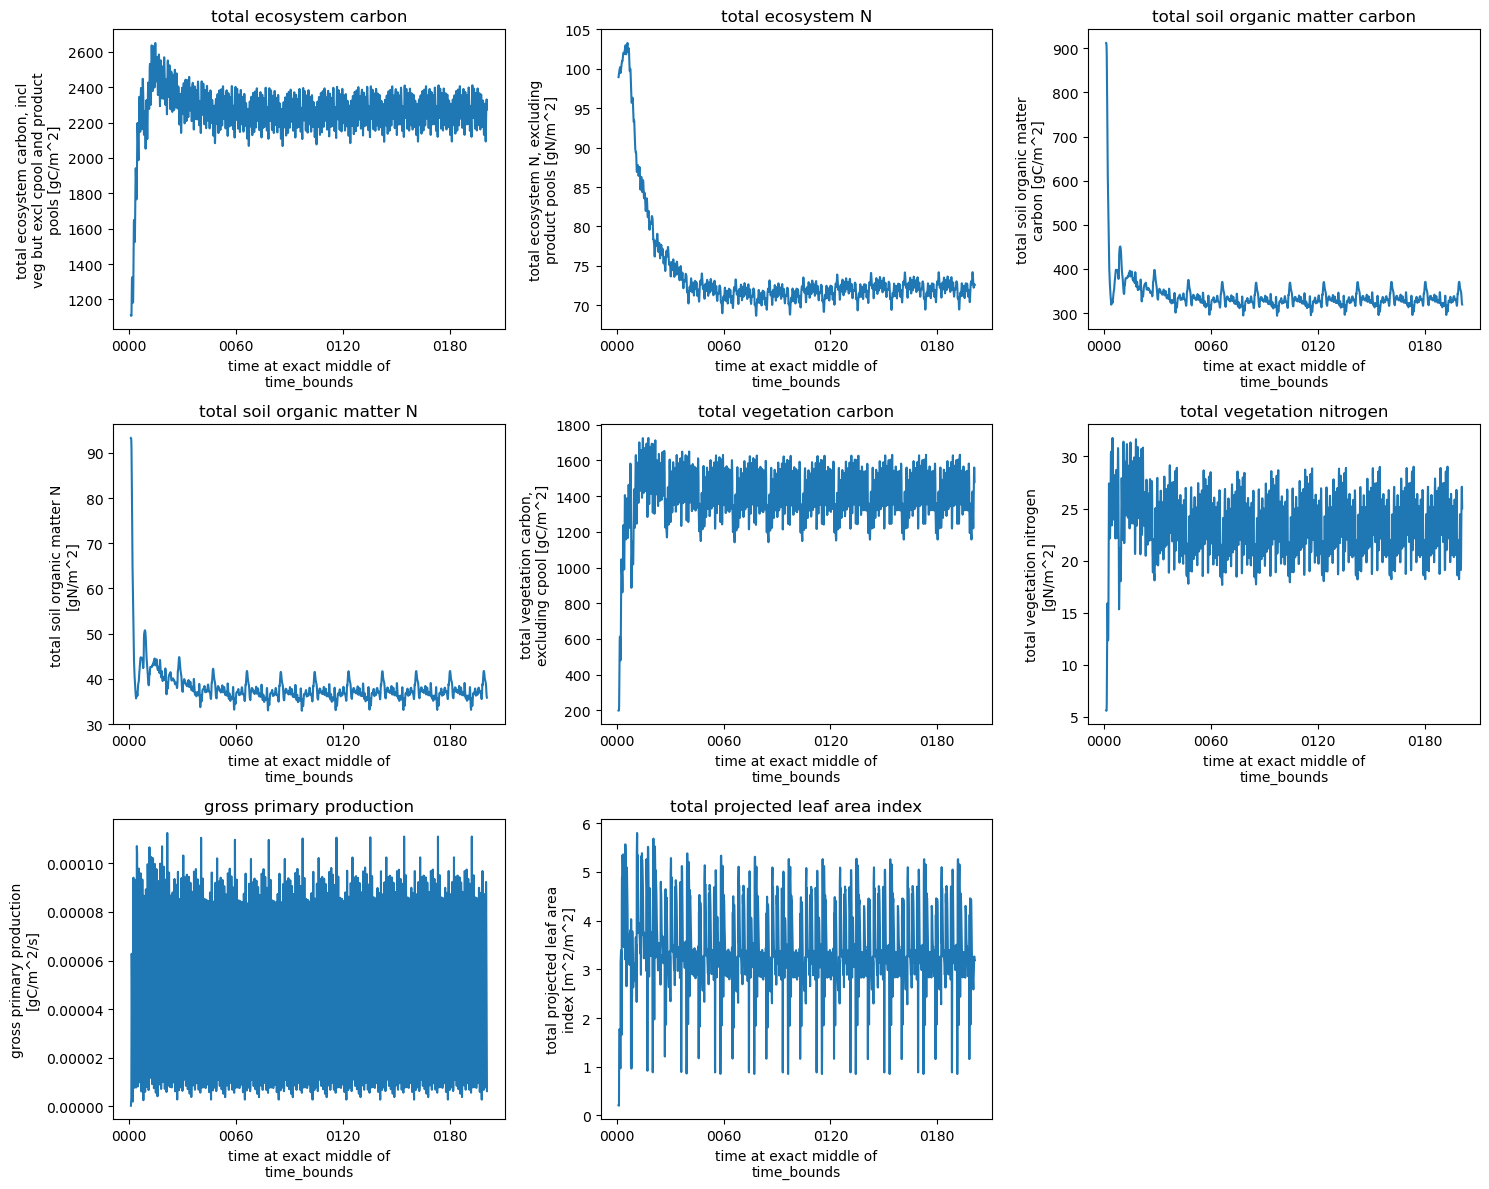

In [28]:
plot_nc_variables(ds_ctsm, ['TOTECOSYSC', 'TOTECOSYSN', 'TOTSOMC', 'TOTSOMN', 'TOTVEGC', 'TOTVEGN', 'GPP', 'TLAI'])